In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

inverse Transform Method（反轉換法）是一種常用於模擬中從均勻分布亂數產生其他機率分布隨機變數的基本技術。它的核心思想是利用機率分布的累積分布函數（CDF）與其反函數來進行轉換。 (only good CDF)

🔁 核心概念
若我們想根據某個機率分布 
𝐹(𝑥)產生隨機變數 𝑋
U∼Uniform(0,1)，那麼：

Inverse Transform Method 的基本步驟為：

U∼Uniform(0,1)，則令

F(x) = U ==> x = F^-1(U)

ex :  x ~ exp(1)  F(x) = 1 - e**-x = U

* x =  - log(U)


so : x ~ exp(lamda)  sample mean = 1 / lambda



In [23]:
u = random.uniform(0,1)

In [24]:
# x~ exp(1)


res = []
for i in range(100000):
    u = random.uniform(0,1)
    x = np.log(1 - u) *-1
    res.append(x)

(array([7.2044e+04, 2.0044e+04, 5.6870e+03, 1.5820e+03, 4.7200e+02,
        1.1900e+02, 4.2000e+01, 6.0000e+00, 3.0000e+00, 1.0000e+00]),
 array([4.28403569e-05, 1.27567964e+00, 2.55131643e+00, 3.82695323e+00,
        5.10259002e+00, 6.37822682e+00, 7.65386362e+00, 8.92950041e+00,
        1.02051372e+01, 1.14807740e+01, 1.27564108e+01]),
 <BarContainer object of 10 artists>)

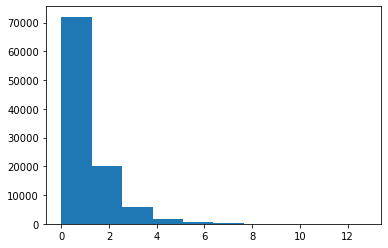

In [26]:
plt.hist(res)

In [17]:
# ex2 間斷分配。 抽到哪個區間，x就等於該變數
'''
高效率方法，從機率大開始抽
'''


def sample_discrete():
    outcomes = ['A', 'B', 'C']
    probs = [0.2, 0.5, 0.3]  # P(A), P(B), P(C)

    # Step 1: 計算累積機率
    cum_probs = [sum(probs[:i+1]) for i in range(len(probs))]

    # Step 2: 產生 u ~ U(0,1)
    u = random.uniform(0, 1)

    # Step 3: 找到 u 落在哪個區間
    for outcome, cp in zip(outcomes, cum_probs):
        if u < cp:
            return outcome

# 示範抽樣
samples = [sample_discrete() for _ in range(1000)]

(array([511.,   0.,   0.,   0.,   0., 208.,   0.,   0.,   0., 281.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

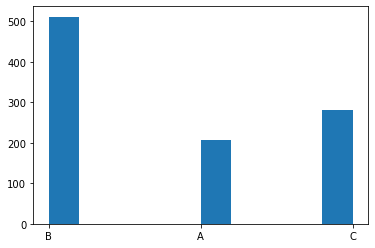

In [23]:
plt.hist(samples)

In [ ]:
# ex3 間斷 uniform
'''
p(x) = 1 / n

x = 1 。 0 <= u <= 1/1

x = 2 。 1 <= u <= 2/1
....
'''

x = int(n * u) + 1

In [ ]:
#acceptance rejection
'''
不需要知道F(x)，也不用常數向

ex:圓的分布。 keep drawing。 if in circle紀錄 else重抽。完全不用pi


生x，但pdf超醜，inverse不可能，積分不可。改生y(proposal density)!! 


cf(y) 罩住 f(x)。 當抽到目標值內接受，否則重抽。 x之值，y必定要抽的到

c值很大，一定抽的到，但很慢，find optimize。


'''

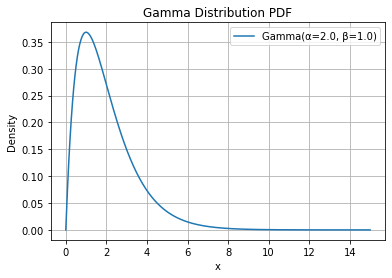

In [ ]:
#ex   x ~ gamma (a, b)

'''
0<x<inf !!
'''

# proposal  選擇 y ~exp(lamda)  why? 皆為單峰且值域相同。當然也能用其他生
from scipy.stats import gamma


# 設定 alpha (形狀), beta (尺度)
alpha = 2.0  # shape
beta = 1.0   # scale

# 建立 x 軸值（密度定義域）
x = np.linspace(0, 15, 500)

# 計算 gamma 分布的 pdf（注意：scale=β）
pdf = gamma.pdf(x, a=alpha, scale=beta)

# 繪圖
plt.plot(x, pdf, label=f'Gamma(α={alpha}, β={beta})')
plt.title('Gamma Distribution PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()




In [5]:
gamma.pdf(u, a=2, scale=1)

0.11469404301025259

In [14]:
x = []

lam = 2
a = 2
scale = 1

# 上限常數 c：max(f(x)/g(x))。理論值約 c = 1.57
c = 1.6

while len(x) < 10000:
    # 產生提議分布樣本（Exponential(2)）
    u1 = random.uniform(0, 1)
    cand = -1 / lam * np.log(u1)

    # 計算 f(x)：gamma(2,1) 的密度
    fx = gamma.pdf(cand, a=a, scale=scale)

    # 計算 g(x)：exponential(2) 的密度
    gx = lam * np.exp(-lam * cand)

    # 接受機率 = f(x) / (c * g(x))
    u2 = random.uniform(0, 1)
    if u2 < fx / (c * gx):
        x.append(cand)

(array([2.405e+03, 4.270e+03, 2.292e+03, 7.020e+02, 2.160e+02, 7.800e+01,
        3.000e+01, 6.000e+00, 0.000e+00, 1.000e+00]),
 array([0.00583678, 0.57749948, 1.14916218, 1.72082488, 2.29248757,
        2.86415027, 3.43581297, 4.00747567, 4.57913837, 5.15080106,
        5.72246376]),
 <BarContainer object of 10 artists>)

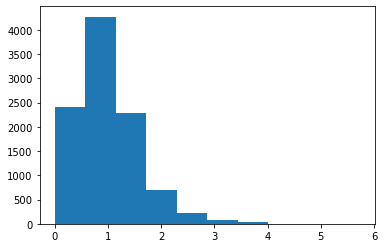

In [15]:
plt.hist(x)

In [ ]:
#ex2 beta(a,b) 。三個方法

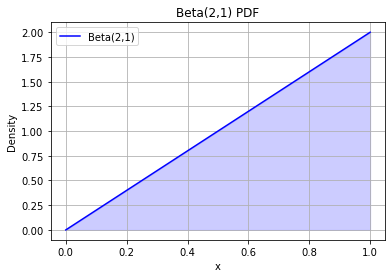

In [60]:
# ar

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

x = np.linspace(0, 1, 500)

# a = 2, b = 1
pdf = beta.pdf(x, a=2, b=1)

# 繪圖
plt.plot(x, pdf, label='Beta(2,1)', color='blue')
plt.fill_between(x, pdf, color='blue', alpha=0.2)
plt.title('Beta(2,1) PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.show()

In [61]:
# f(x) = 2x beta(2,1)

def ar(n):
    x = []
    
    while True:
        if len(x) >= n:
            break
        
        
        u1 = random.uniform(0,1)
        u2 = random.uniform(0,1)
        
        if u2 <= u1:
            x.append(u1)
    return x

(array([ 138.,  329.,  495.,  728.,  931., 1056., 1302., 1470., 1672.,
        1879.]),
 array([0.01105242, 0.10994321, 0.208834  , 0.30772479, 0.40661558,
        0.50550636, 0.60439715, 0.70328794, 0.80217873, 0.90106952,
        0.99996031]),
 <BarContainer object of 10 artists>)

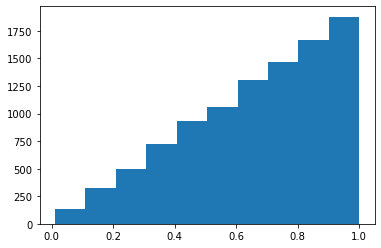

In [62]:
x = ar(10000)

plt.hist(x)

In [67]:
# 3
x= []
for i in range(100000):
    u1 = random.uniform(0,1)
    u2 = random.uniform(0,1)
    
    y1 = u1 ** (1/2)
    y2 = u2
    
    if y1 + y2 <= 1:
        x.append(y1/ (y1+y2))

(array([ 344., 1029., 1645., 2359., 3090., 3656., 4328., 4936., 5690.,
        6363.]),
 array([0.00347518, 0.10312761, 0.20278004, 0.30243247, 0.4020849 ,
        0.50173732, 0.60138975, 0.70104218, 0.80069461, 0.90034704,
        0.99999947]),
 <BarContainer object of 10 artists>)

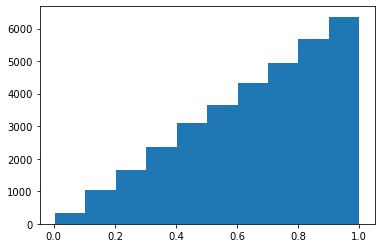

In [68]:
plt.hist(x)

In [19]:
#ex3 Z(0,1)  值域 (-inf, inf) 難找。切一半!再展開


def generate_z():
    x = []
    
    while True:
        if len(x) >10000:
            break
            
        u1 = random.uniform(0,1)
    
        y = -1 * np.log(u1) # 生成exp(1)
        u2 = random.uniform(0,1)
    
        if u2 <= (np.exp(-1 * ((y-1)**2) / 2)):
            x.append(y)
            
    return x

In [21]:
a = generate_z()

(array([3176., 2726., 1928., 1146.,  618.,  264.,   96.,   36.,    6.,
           5.]),
 array([1.51486859e-04, 4.12760634e-01, 8.25369781e-01, 1.23797893e+00,
        1.65058808e+00, 2.06319722e+00, 2.47580637e+00, 2.88841552e+00,
        3.30102467e+00, 3.71363381e+00, 4.12624296e+00]),
 <BarContainer object of 10 artists>)

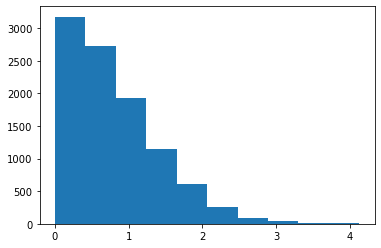

In [22]:
plt.hist(a) # 一半

In [23]:
def generate_z():
    x = []
    
    while True:
        if len(x) >10000:
            break
            
        u1 = random.uniform(0,1)
        u2 = random.uniform(0,1)
        
        y1 = -1 * np.log(u1) # 生成exp(1)
        y2 = -1 * np.log(u2) # 生成exp(1)
        y = 0
        if y2 - ((y1-1)**2 /2) > 0:
            
            y = y2 - ((y1-1)**2 /2)
            u = random.uniform(0,1)
            
            if u <=0.5:
                x.append(y)
            else:
                x.append(-y)
           
            
            
    return x

In [25]:
a = generate_z()

(array([6.000e+00, 3.900e+01, 2.090e+02, 1.365e+03, 6.131e+03, 1.908e+03,
        2.930e+02, 4.300e+01, 5.000e+00, 2.000e+00]),
 array([-8.82309772, -6.90096021, -4.97882269, -3.05668517, -1.13454765,
         0.78758987,  2.70972739,  4.6318649 ,  6.55400242,  8.47613994,
        10.39827746]),
 <BarContainer object of 10 artists>)

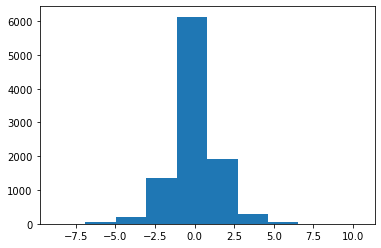

In [26]:
plt.hist(a)

In [ ]:
'''
composition method

f 為一堆pdf相加，可分別計算。

ai：混合權重，為一組機率值


or 

條件分布比較好生，先生y，最後插回x


'''

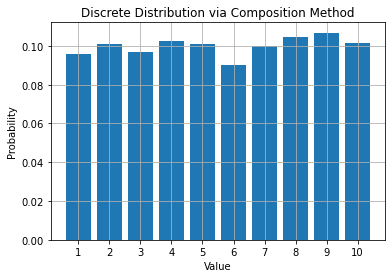

In [48]:

def composition_sample(n):
    samples = []
    for _ in range(n):
        if np.random.uniform() < 0.5:
            # 從 U1: 均勻抽 1~5
            x = np.random.randint(1, 6)
        else:
            # 從 U2: 均勻抽 6~10
            x = np.random.randint(6, 11)
        samples.append(x)
    return samples

# 示範：產生 10,000 筆樣本
samples = composition_sample(10000)

# 畫直方圖
import matplotlib.pyplot as plt
plt.hist(samples, bins=np.arange(1,12)-0.5, rwidth=0.8, density=True)
plt.xticks(range(1, 11))
plt.title('Discrete Distribution via Composition Method')
plt.xlabel('Value')
plt.ylabel('Probability')
plt.grid(True)
plt.show()


In [ ]:
#random vectors

'''
若一組多變量離散變數 
(X1,X2,...,X r)，我們可透過「逐步生成」方式模擬其實現值：

先模擬 
𝑋1
再模擬 
𝑋2（條件為已知 

依此類推直到 𝑋𝑟



'''

In [ ]:
# Trial-by-Trial 模擬法（當 𝑟≫𝑛)

In [47]:
import numpy as np

def multinomial_trial_by_trial(n, p):
    outcomes = np.random.choice(len(p), size=n, p=p)
    counts = np.bincount(outcomes, minlength=len(p))
    return counts

# 比如：擲 10 次，結果有 4 種，機率如下
print(multinomial_trial_by_trial(10, [0.1, 0.2, 0.4, 0.3]))

[1 2 4 3]


In [ ]:
#這時可以利用每一維的條件分布來分段模擬：
'''
X1∼Bin(n,p1)

x2 Bin (n -x1, p2/(1-p1))
....
'''

In [ ]:
# homework 2 

'''

F(x)=0.5(x+x**2)

1. inverse

2. accept reject

3. composition

'''

In [36]:
# 1 
'''
U = 0.5(x+x**2)

反函數 : x = (-1 +(1+8U)**0.5) * 0.5

'''


random.seed(999)

x = []
for i in range(100000):
    u = random.uniform(0,1)
    
    x.append((-1 +(1+8*u)**0.5) * 0.5)
    


(array([ 5510.,  6626.,  7586.,  8339.,  9364., 10444., 11566., 12585.,
        13529., 14451.]),
 array([7.20131495e-05, 1.00063552e-01, 2.00055090e-01, 3.00046629e-01,
        4.00038167e-01, 5.00029705e-01, 6.00021244e-01, 7.00012782e-01,
        8.00004321e-01, 8.99995859e-01, 9.99987398e-01]),
 <BarContainer object of 10 artists>)

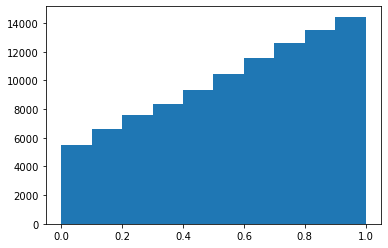

In [38]:
plt.hist(x)

In [ ]:
#2


# 值域 X(0,1) proposal density U(0, 1) f(x) = 1

# f(x) = 0.5 + x


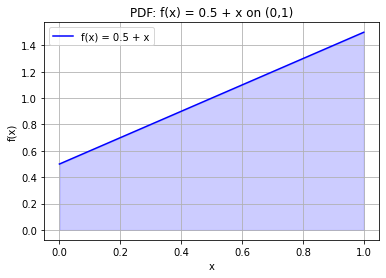

In [39]:
x = np.linspace(0, 1, 500)
f_x = 0.5 + x

plt.plot(x, f_x, label='f(x) = 0.5 + x', color='blue')
plt.fill_between(x, f_x, alpha=0.2, color='blue')
plt.title('PDF: f(x) = 0.5 + x on (0,1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

In [43]:
# 由圖可知 c == 1.5 。最佳值


'''
u1 u2 (0, 1)


if u2 <= (2/3)*(0.5+y) 。 x = y 

else重抽

'''



def ar(n):
    
    x = []
    
    while True:
        if len(x) >= n:
            break
        
        
        u1 = random.uniform(0,1)
        u2 = random.uniform(0,1)
        
        if u2 <= (2/3)*(0.5+ u1):
            x.append(u1)
    return x

In [44]:
y = ar(10000)

(array([ 568.,  618.,  719.,  797.,  971., 1050., 1133., 1277., 1401.,
        1466.]),
 array([4.13094369e-04, 1.00359970e-01, 2.00306846e-01, 3.00253722e-01,
        4.00200598e-01, 5.00147473e-01, 6.00094349e-01, 7.00041225e-01,
        7.99988101e-01, 8.99934977e-01, 9.99881852e-01]),
 <BarContainer object of 10 artists>)

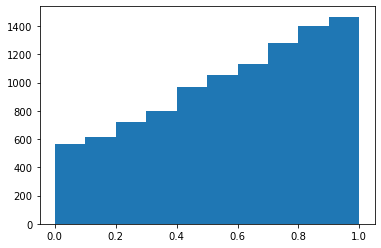

In [46]:
plt.hist(y)

In [50]:
#3 composition 機率相加 ==1
'''

f(x) = 0.5 + x == >  0.5(g1(x)) + 0.5(g2(x))

g1(x) = 1 反函數 u

g2(x) = 2x 反函數 x = u**0.5
 
'''

def compo(n):
    
    x = []
    
    while True:
        if len(x) >= n:
            break
        
        u1 = random.uniform(0, 1)
        u2 = random.uniform(0, 1)
        if u1 > 0.5:
            x.append(u2)
            
        else:
            x.append(u2**0.5)

            
    return x

In [51]:
x = compo(100000)

(array([ 5434.,  6395.,  7374.,  8627.,  9336., 10613., 11573., 12589.,
        13515., 14544.]),
 array([4.20171606e-05, 1.00037725e-01, 2.00033432e-01, 3.00029140e-01,
        4.00024848e-01, 5.00020555e-01, 6.00016263e-01, 7.00011971e-01,
        8.00007678e-01, 9.00003386e-01, 9.99999094e-01]),
 <BarContainer object of 10 artists>)

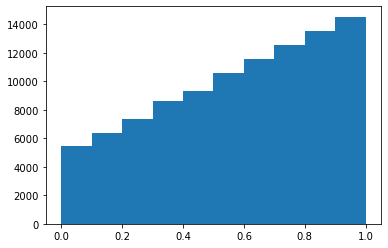

In [52]:
plt.hist(x)

In [ ]:
# f(x) = 0.25 + 2x**3 + 5/4 x**4

In [58]:
def ar(n):
    x = []
    
    while True:
        if len(x) >= n:
            break
        
        u1 = random.uniform(0,1)
        u2 = random.uniform(0,1)
        
        if u2 <= (2/7) * (0.25 + (2 * u1**3) + (5/4)*(u1**4)):
            x.append(u1)
    return x

(array([ 2506.,  2536.,  2891.,  3596.,  4870.,  7034., 10172., 14957.,
        21385., 30053.]),
 array([1.00712512e-05, 1.00008961e-01, 2.00007851e-01, 3.00006740e-01,
        4.00005630e-01, 5.00004519e-01, 6.00003409e-01, 7.00002299e-01,
        8.00001188e-01, 9.00000078e-01, 9.99998968e-01]),
 <BarContainer object of 10 artists>)

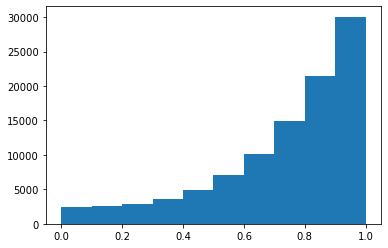

In [59]:
x = ar(100000)
plt.hist(x)